In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

In [4]:
from sklearn.model_selection import train_test_split, StratifiedKFold,cross_val_score,GridSearchCV
from sklearn.preprocessing import StandardScaler,MinMaxScaler,OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [9]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report

In [11]:
import joblib
import warnings
warnings.filterwarnings("ignore")

In [12]:
# loading dataset
df  = pd.read_csv('Bank Customer Churn Prediction.csv')

In [13]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [14]:
df.shape

(10000, 12)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [16]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [20]:
#checking any missing values

df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [21]:
df['churn'].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

In [22]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

<Axes: xlabel='gender', ylabel='count'>

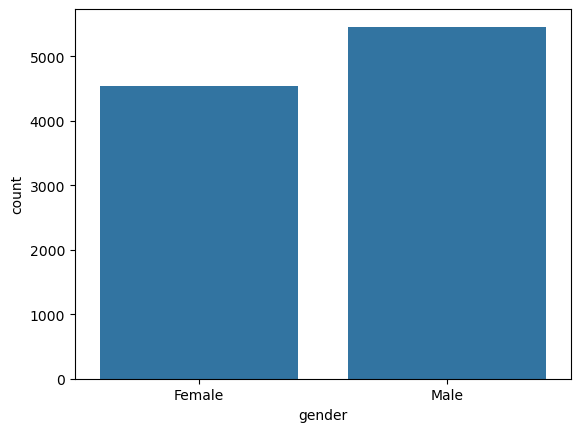

In [ ]:
sns.countplot(x = "gender",data = df)

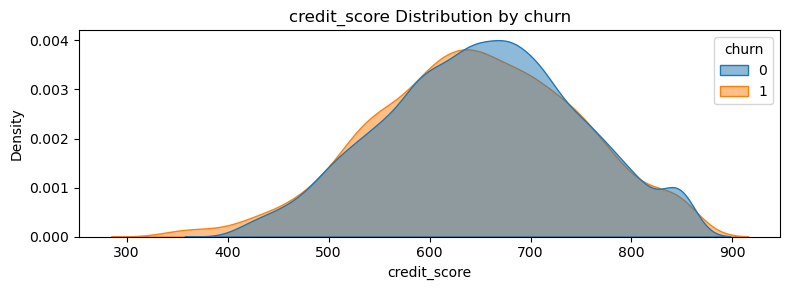

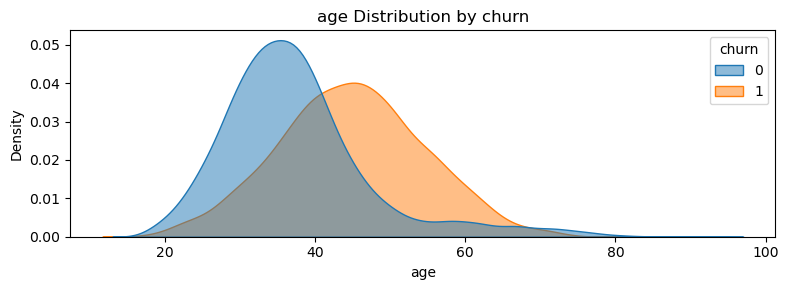

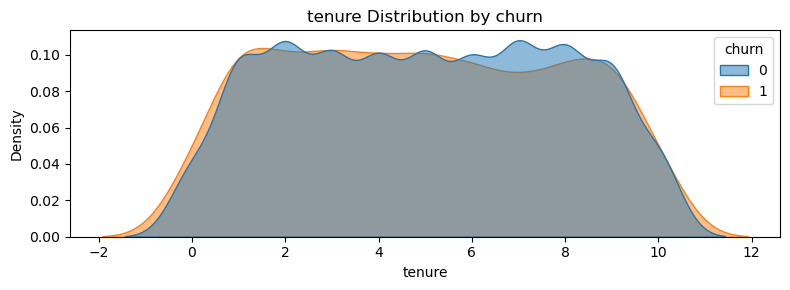

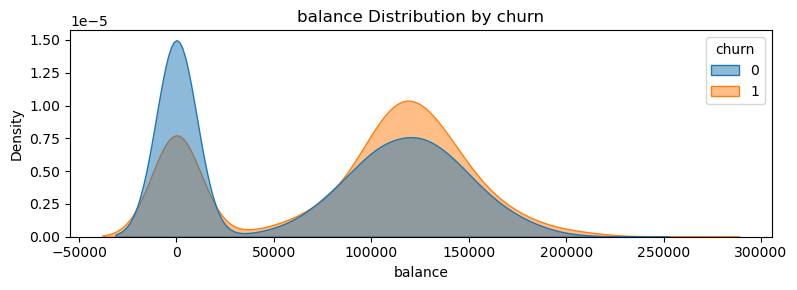

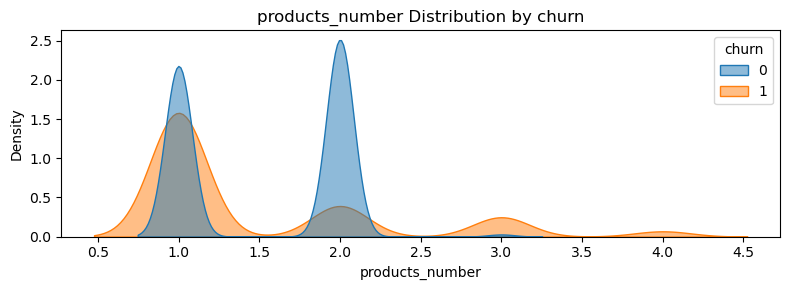

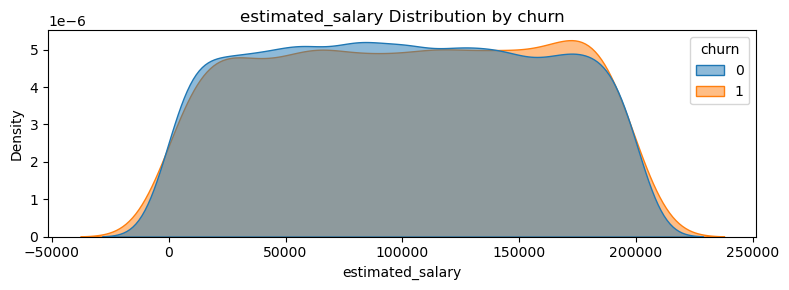

In [26]:
num_cols = ['credit_score','age','tenure','balance','products_number','estimated_salary']

for col in num_cols:
    plt.figure(figsize = (8,3))
    sns.kdeplot(data = df,x=col,hue = 'churn',fill = True,common_norm = False,alpha = 0.5)
    plt.title(f'{col} Distribution by churn')
    plt.tight_layout()
    plt.show()

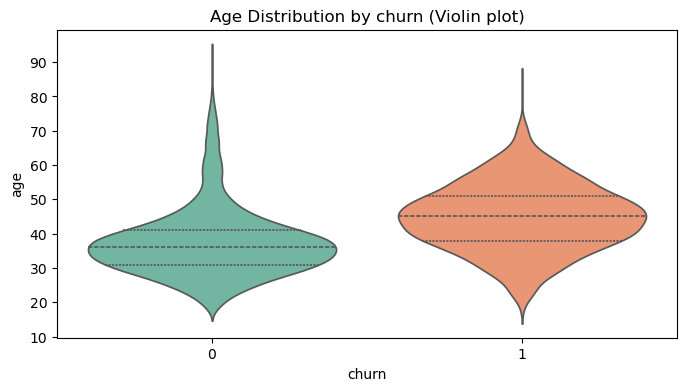

In [27]:
# violin plot
plt.figure(figsize = (8,4))
sns.violinplot(data = df,x='churn',y='age',inner = 'quart',palette = 'Set2')
plt.title('Age Distribution by churn (Violin plot)')
plt.show()

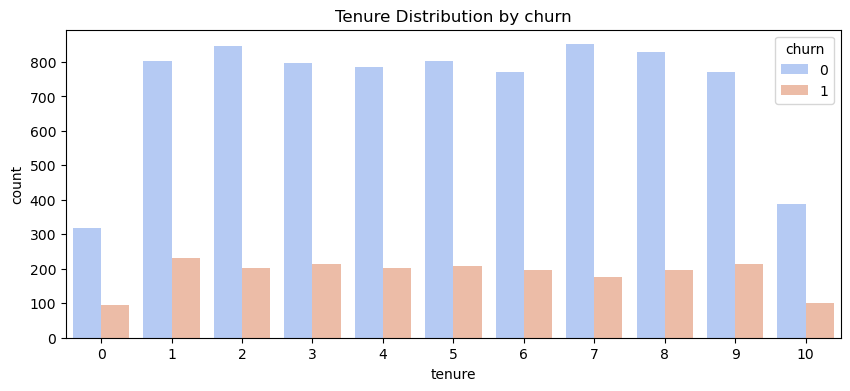

In [29]:
# Tenure distribution

plt.figure(figsize = (10,4))
sns.countplot(data = df,x='tenure',hue = 'churn',palette = 'coolwarm')
plt.title('Tenure Distribution by churn')
plt.show()

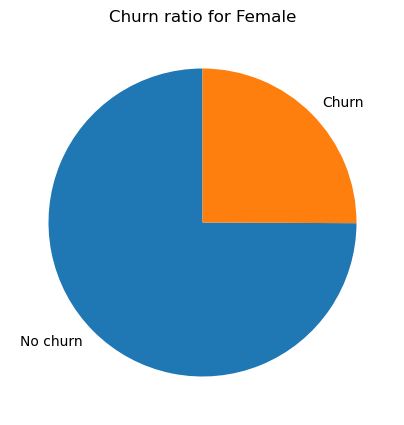

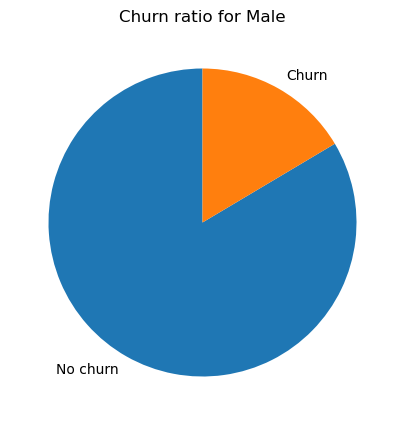

In [35]:
# Gender vs churn
gender_counts = df.groupby('gender')['churn'].value_counts(normalize = True).unstack().fillna(0)

for gender in gender_counts.index:
    plt.figure(figsize = (5,5))
    plt.pie(gender_counts.loc[gender],labels = ['No churn','Churn'],startangle = 90)
    
    plt.title(f'Churn ratio for {gender}')

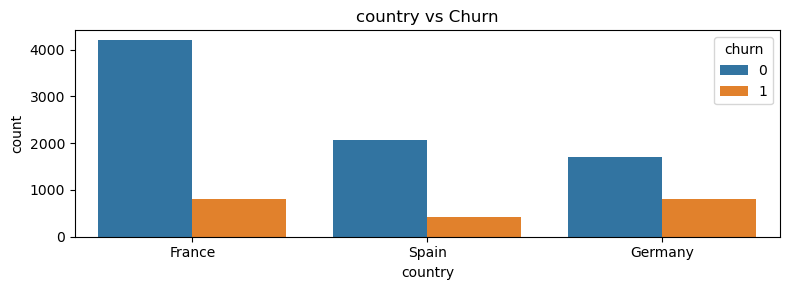

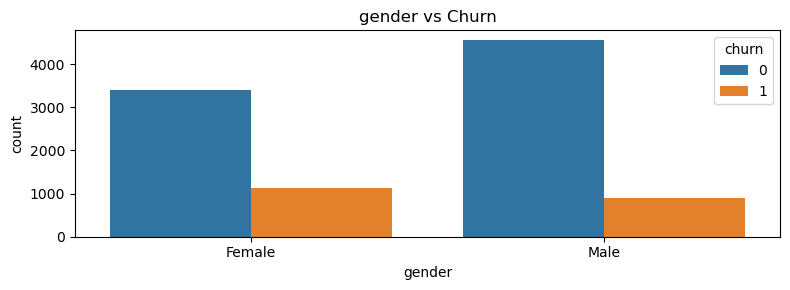

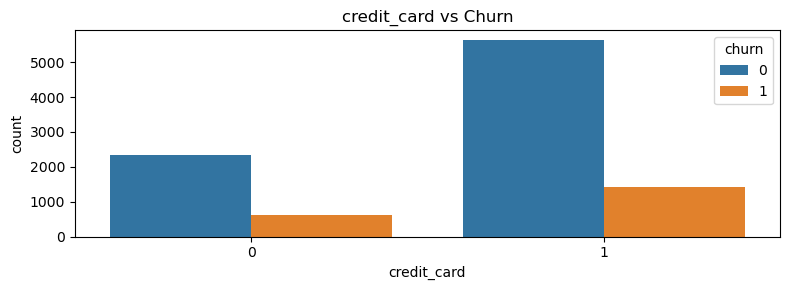

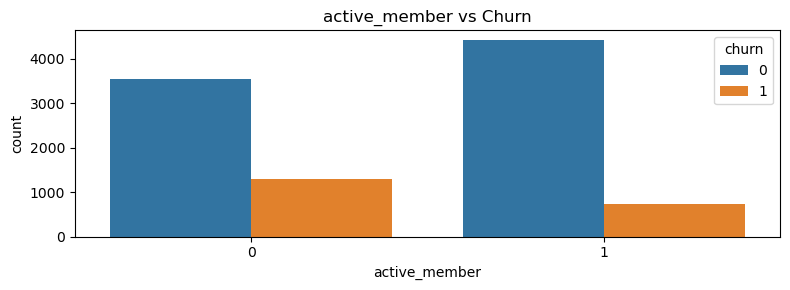

In [41]:
# categorical features
cat_cols = ['country','gender','credit_card','active_member']

for c in cat_cols:
    plt.figure(figsize=(8,3))
    sns.countplot(data = df,x=c,hue = 'churn')
    plt.title(f'{c} vs Churn')
    plt.tight_layout()
    plt.show()

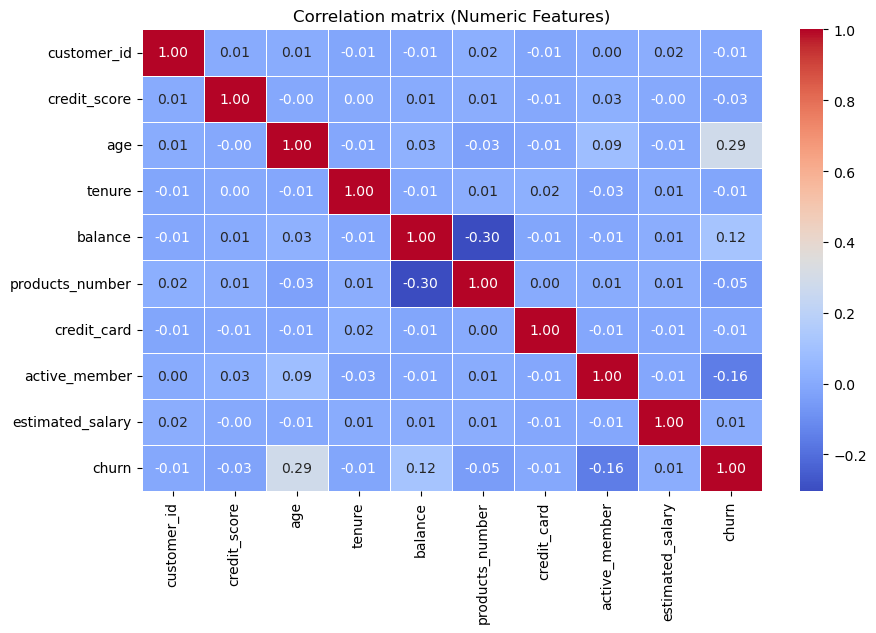

In [49]:
# heatmap visualization

corr = df.corr(numeric_only =True)

plt.figure(figsize = (10,6))
sns.heatmap(corr,annot = True,fmt = '.2f',cmap = 'coolwarm',linewidth = 0.5)
plt.title("Correlation matrix (Numeric Features)")
plt.show()

In [50]:
# plottinh heatmap for numeric data

numeric_data = df[num_cols]
corr = numeric_data.corr()
corr.style.background_gradient(cmap= 'coolwarm')

,credit_score,age,tenure,balance,products_number,estimated_salary
credit_score,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.001384
age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.007201
tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.007784
balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,0.012797
products_number,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.014204
estimated_salary,-0.001384,-0.007201,0.007784,0.012797,0.014204,1.000000


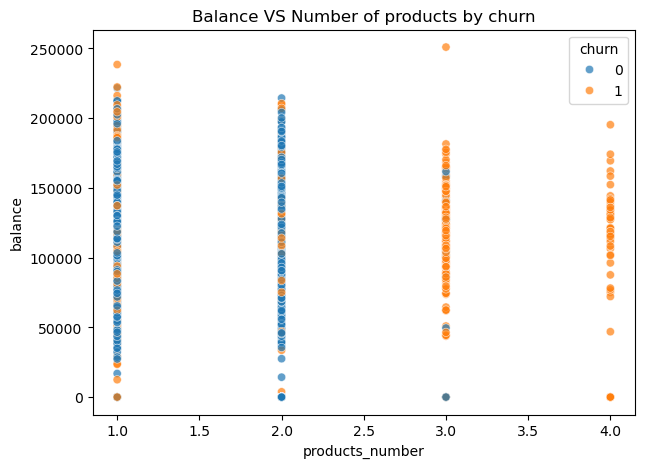

In [51]:
# Balance VS Products 
plt.figure(figsize = (7,5))
sns.scatterplot(data = df,x='products_number',y = 'balance',hue='churn',alpha = 0.7)
plt.title("Balance VS Number of products by churn")
plt.show()

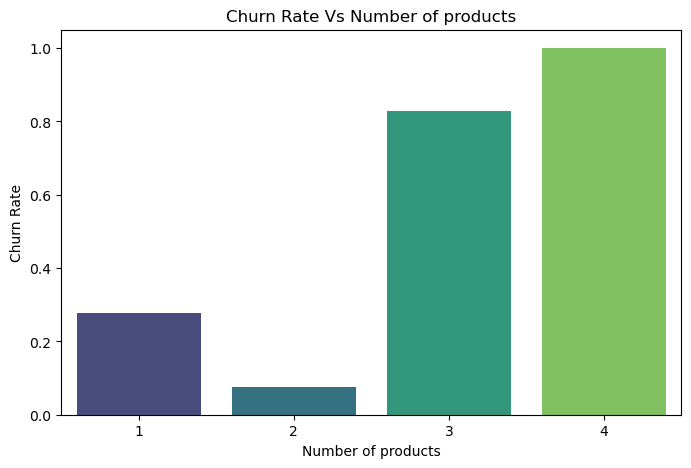

In [53]:

# aggregate churn rate per number of products
churn_rate = df.groupby('products_number')['churn'].mean().reset_index()

plt.figure(figsize = (8,5))
sns.barplot(data = churn_rate,x='products_number',y='churn',palette = 'viridis')
plt.xlabel('Number of products')
plt.ylabel('Churn Rate')
plt.title('Churn Rate Vs Number of products')
plt.show()

In [54]:
# Feature engineering 
df_fe = df.copy()

# Balance per products
df_fe['balance_per_product'] = df_fe['balance'] / (df_fe['products_number'].replace(0,np.nan))
df_fe['balance_per_product'].fillna(0,inplace = True)


In [57]:
# Salary to balance ration

df_fe['salary_balance_ratio'] = df_fe['estimated_salary'] / (df_fe['balance'].replace(0,np.nan))
df_fe['salary_balance_ratio'].replace([np.inf,-np.inf],np.nan,inplace = True)
df_fe['salary_balance_ratio'].fillna(df_fe['salary_balance_ratio'].median(),inplace = True)

In [58]:
# age groups
bins = [0,25,35,45,55,65,100]
labels = ['<25','25-34','35-44','45-54','55-64','65+']
df_fe['age_group'] = pd.cut(df_fe['age'],bins = bins,labels = labels)

In [59]:
# Tenure bucket
df_fe['tenure_bucket'] = pd.cut(df_fe['tenure'],bins = [-1,0,2,5,10,100],labels = ['0','1-2','3-5','6-10','10+'])


In [60]:
# Flag high balance

df_fe['high_balance'] = (df_fe['balance'] > df_fe['balance'].quantile(0.75)).astype(int)

In [61]:
# Quick checks

df_fe[['balance_per_product','salary_balance_ratio','age','age_group','tenure','tenure_bucket','high_balance']].head()

,balance_per_product,salary_balance_ratio,age,age_group,tenure,tenure_bucket,high_balance
0,0.000000,0.839258,42,35-44,2,1-2,0
1,83807.860000,1.342864,41,35-44,1,1-2,0
2,53220.266667,0.713585,42,35-44,8,6-10,1
3,0.000000,0.839258,39,35-44,1,1-2,0
4,125510.820000,0.630098,43,35-44,2,1-2,0


In [62]:
# Encoding & Scaling

target = 'churn'
drop_cols = ['customer_id']

features = [c for c in df_fe.columns if c not in [target] + drop_cols]

numeric_features = ['credit_score','age','tenure','balance','products_number','estimated_salary','balance_per_product','salary_balance_ratio']
categorical_features = ['country','gender','credit_card','active_member','age_group','tenure_bucket','high_balance']

df_fe[categorical_features] = df_fe[categorical_features].astype('object')

numeric_transformer = Pipeline([
    ('imputer',SimpleImputer(strategy = 'median')),
    ('scaler',StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer',SimpleImputer(strategy = 'most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown = 'ignore',sparse_output = False))
])

preprocessor = ColumnTransformer([
    ('num',numeric_transformer,numeric_features),
    ('cat',categorical_transformer,categorical_features)

])

print('Numeric features:',numeric_features)
print('Categorical features:',categorical_features)

Numeric features: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary', 'balance_per_product', 'salary_balance_ratio']
Categorical features: ['country', 'gender', 'credit_card', 'active_member', 'age_group', 'tenure_bucket', 'high_balance']


In [63]:
# Train-Test-Split
X = df_fe[features]
y = df_fe[target]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,stratify = y,random_state =42)


In [66]:
# Training models 
models = {
    'LogisticRegression': LogisticRegression(max_iter =500),
    'RandomForest' : RandomForestClassifier(n_estimators = 200,random_state =42),
    'GradientBoosting':GradientBoostingClassifier(n_estimators = 200,random_state = 42),
    'AdaBoost' : AdaBoostClassifier(n_estimators = 200,random_state = 42),
    'SVC': SVC(probability = True,random_state = 42)
}

cv = StratifiedKFold(n_splits = 5,shuffle = True,random_state = 42)
results = {}

for name,model in models.items():
    pipe = Pipeline(steps = [('preprocessor',preprocessor),('classifier',model)])
    scores = cross_val_score(pipe,X_train,y_train,cv = cv, scoring = 'roc_auc',n_jobs = -1)
    results[name] = scores
    print(f"{name} AUC: Mean={scores.mean():4f} Std = {scores.std():.4f}")

LogisticRegression AUC: Mean=0.787750 Std = 0.0244
RandomForest AUC: Mean=0.848597 Std = 0.0130
GradientBoosting AUC: Mean=0.862778 Std = 0.0097
AdaBoost AUC: Mean=0.846153 Std = 0.0133
SVC AUC: Mean=0.835128 Std = 0.0104


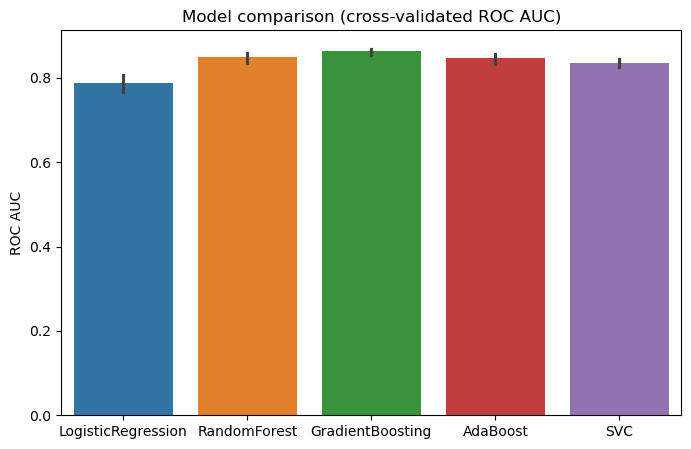

In [70]:
# boxplot of cv auc socres
plt.figure(figsize = (8,5))
sns.barplot(data = [results[m] for m in list(results.keys())])
plt.xticks(ticks = range(len(results)), labels = list(results.keys()))
plt.ylabel('ROC AUC')
plt.title('Model comparison (cross-validated ROC AUC)')
plt.show()

In [71]:
# Fit best model on train set
best_name = max(results.keys(),key = lambda k : results[k].mean())
best_name , results[best_name].mean()

('GradientBoosting', np.float64(0.8627777349731776))

In [72]:
best_model = models[best_name]
best_pipeline = Pipeline(steps = [('preprocessor',preprocessor),
('classifier',best_model)])

best_pipeline.fit(X_train,y_train)



,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Test Accuracy: 0.8680
Test Precision: 0.7804
Test Recall: 0.4889
Test F1-score: 0.6012
Test ROC AUC: 0.8692

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.78      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



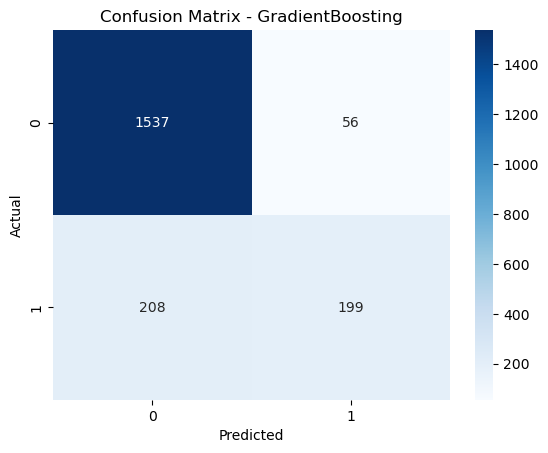

In [74]:
# Predictions

y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:,1]

#Metrics

acc = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
rec = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
roc = roc_auc_score(y_test,y_proba)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {rec:.4f}")
print(f"Test F1-score: {f1:.4f}")
print(f"Test ROC AUC: {roc:.4f}")


print("\nClassification Report:")
print(classification_report(y_test,y_pred))

# Confusion matrix

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot = True,fmt='d',cmap = 'Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()


In [76]:
# Saving model
joblib.dump(best_pipeline,'churn_model.pkl')
print("Saved pipeline : churn_model.pkl")

Saved pipeline : churn_model.pkl


In [78]:
#--- New customer sample ---
sample = {
    'customer_id': 373292028,
    'credit_score': 650,
    'country': 'France',
    'gender': 'Male',
    'age': 40,
    'tenure': 3,
    'balance': 50000.0,
    'products_number': 2,
    'credit_card': 1,
    'active_member': 1,
    'estimated_salary': 60000.0
}

sample_df = pd.DataFrame([sample])

# --- Apply same feature engineering ---
sample_df['balance_per_product'] = sample_df['balance'] / (sample_df['products_number'].replace(0, np.nan))
sample_df['balance_per_product'].fillna(0, inplace=True)

sample_df['salary_balance_ratio'] = sample_df['estimated_salary'] / (sample_df['balance'].replace(0, np.nan))
sample_df['salary_balance_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
sample_df['salary_balance_ratio'].fillna(sample_df['salary_balance_ratio'].median(), inplace=True)

bins = [0,25,35,45,55,65,100]
labels = ['<25','25-34','35-44','45-54','55-64','65+']
sample_df['age_group'] = pd.cut(sample_df['age'], bins=bins, labels=labels)

sample_df['tenure_bucket'] = pd.cut(sample_df['tenure'], bins=[-1,0,2,5,10,100], labels=['0','1-2','3-5','6-10','10+'])
sample_df['high_balance'] = (sample_df['balance'] > 50000.0).astype(int)  # can use 75th percentile of training set


# --- Drop ID ---
sample_df = sample_df.drop(columns=['customer_id'])

# --- Predict ---
pred = best_pipeline.predict(sample_df)[0]
prob = best_pipeline.predict_proba(sample_df)[0,1]

print(f'Predicted churn: {pred}, probability of churn: {prob:.3f}')

Predicted churn: 0, probability of churn: 0.030
